# Preparations

In [2]:
import pandas as pd
import math
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

# Layout

In [3]:
def mm_to_pixel(size_mm, dpi):
    """Convert millimeters to pixels based on the given DPI."""
    inches = size_mm / 25.4     # Convert mm to inches
    pixels = inches * dpi       # Convert inches to pixels
    return int(pixels)

Aviable format on "DM Fotoparadies" are:

- 127 × 89
- 152 × 102
- 169 × 114
- 178 × 127

In [5]:
# Print size
print_width_mm = 178
print_height_mm = 127

# Print layout
image_cols = 2
image_rows = 1

# Calculate size of single image included the border
image_width_mm = print_width_mm / image_cols
image_height_mm = print_height_mm / image_rows
print(f"Image size (WxH): {image_width_mm} x {image_height_mm} mm")

# Define border and calculate picture size
side_border_mm = 5
bottom_border_mm = 15
picture_width_mm = image_width_mm - 2*side_border_mm
picture_height_mm = image_height_mm - side_border_mm - bottom_border_mm
print(f"Picture size (WxH): {picture_width_mm} x {picture_height_mm} mm")

# Calculate matching aspects
aspect = picture_width_mm / picture_height_mm
print('Matching aspects (W:H): ', end='')
for i in range(1, 8):
      print(f'{i}:{round(aspect*i, 1)}', end=' | ')
print()

# Calculate optimal picture resolution
dpi = 300
picture_width_px = mm_to_pixel(picture_width_mm, dpi)
picture_height_px = mm_to_pixel(picture_height_mm, dpi)
print(f"Picture resolution (WxH) to get {dpi} dpi: {picture_width_px} x {picture_height_px}")

image_width_px = mm_to_pixel(image_width_mm, dpi)
image_height_px = mm_to_pixel(image_height_mm, dpi)

Image size (WxH): 89.0 x 127.0 mm
Picture size (WxH): 79.0 x 107.0 mm
Matching aspects (W:H): 1:0.7 | 2:1.5 | 3:2.2 | 4:3.0 | 5:3.7 | 6:4.4 | 7:5.2 | 
Picture resolution (WxH) to get 300 dpi: 933 x 1263


### Steps to perform

- copy all images to a single folder
- rename them according to the content of the image
- reshape them to the selected aspect ratio
- resizing is not necessary it will be done later automatically

# Pictures

In [7]:
# Select input directory and list image files
path_to_input_dir = Path('C:/Users/thoma/OneDrive/HOCHZEIT/Fotowand/Fotos')
image_files = list(path_to_input_dir.glob('*.jpg')) + list(path_to_input_dir.glob('*.jpeg')) + list(path_to_input_dir.glob('*.png'))
print(f"Found {len(image_files)} image files in {path_to_input_dir}")

# Create a list to store image information
image_info_list = []
image_info_list.append(['Filename', 'Width (px)', 'Height (px)', 'Date'])

# Loop through image files and extract information
for image_file in image_files:
    try:
        with Image.open(image_file) as img:

            filename = image_file.name
            width, height = img.size
            
            # Extract EXIF data if available and get the original datetime
            exif_data = img._getexif() # type: ignore
            if exif_data:
                datetime_original = exif_data.get(36867)

            else:
                print(f"No EXIF data found for {filename}")

            image_info_list.append([filename, width, height, datetime_original if exif_data else 'N/A']) # type: ignore

    except Exception as e:
        print(f"Error processing {image_file}: {e}")

# Create a DataFrame
image_info_df = pd.DataFrame(image_info_list[1:], columns=image_info_list[0])
image_info_file = path_to_input_dir.parent / 'image_info.xlsx'

# Add columns to manually add description and date corrected
image_info_df['Description'] = ''
image_info_df['Date corrected'] = ''
image_info_df = image_info_df[['Filename', 'Description', 'Width (px)', 'Height (px)', 'Date', 'Date corrected']]

image_info_df.to_excel(image_info_file, index=False)
image_info_df

Found 11 image files in C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\Fotos
No EXIF data found for Diplom Medizin und Nora.jpg


,Filename,Description,Width (px),Height (px),Date,Date corrected
0,20200524_123635.jpg,,4032,3024,2020:05:24 12:36:35,
1,Bergsee in Ulten.jpg,,2055,2740,2020:05:24 12:36:35,
2,Diplom Medizin und Nora.jpg,,2056,2742,N/A,
3,Gardasee mit Fahhrad.jpg,,2293,3058,2019:09:07 13:06:01,
4,Gipfelkreuz bei WK Ausflug.JPG,,3302,4476,2022:07:30 14:31:23,
5,Hochzeit von Christian.jpg,,768,1024,NaN,
6,Klemi in New York.JPG,,3024,4032,2023:02:19 17:00:18,
7,Klemi mit Maske.JPG,,750,1000,2026:03:21 17:25:21,
8,Pool am Gardasee.JPG,,2411,3215,2021:06:19 18:58:09,
9,Schöneck im Winter.JPG,,2757,3676,2021:01:09 12:31:08,


### Steps to perform

- check and add the description and the date in the excel file
- check if the size is at least as big as the calculated minimum size

# Processing

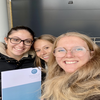

In [8]:
def scale_image_to_width_and_height(img, target_width, target_height, print_aspect_mismatch=False):
    """Scale an image to the target width and height while maintaining the aspect ratio."""

    # Get the original dimensions of the image
    original_width, original_height = img.size

    # Calculate the missmatch in aspect ratio and print it if desired
    if print_aspect_mismatch:
        aspect_original = original_width / original_height
        aspect_target = target_width / target_height
        print(f"Difference in aspect ratio: {aspect_original - aspect_target:.2f}")

    # Return the resized image
    return img.resize((target_width, target_height), Image.Resampling.LANCZOS)

img = Image.open(image_files[2])
scale_image_to_width_and_height(img, 100, 100)

In [9]:
def add_border_to_image(img, image_width_px, image_height_px, border_color='white'):
    """Add a border to an image to fit it into the target dimensions."""

    # Create a new image with the target dimensions and the specified border color
    bordered_img = Image.new('RGB', (image_width_px, image_height_px), border_color)

    # Paste the original image onto the bordered image
    x_y_offset = mm_to_pixel(side_border_mm, dpi)
    bordered_img.paste(img, (x_y_offset, x_y_offset))

    return bordered_img

img = Image.open(image_files[2])
scaled_img = scale_image_to_width_and_height(img, picture_width_px, picture_height_px)
bordered_img = add_border_to_image(scaled_img, image_width_px, image_height_px)

# Save the processed image
output_dir = path_to_input_dir.parent / 'processed_images'
output_dir.mkdir(exist_ok=True)
bordered_img.save(output_dir / 'processed_image.jpg')

In [10]:
def add_description_and_date(img, description='', date='', font_path=None, font_size=42):
    """Add a description and date to the bottom of the image.
    Uses font metrics for vertical layout, so descenders (p, q, j, ...) do not shift text position."""

    # Create a image box for the description and date
    description_box_height_px = mm_to_pixel(bottom_border_mm, dpi)
    description_box = Image.new('RGB', (img.width, description_box_height_px), 'white')

    # Add the description and date to the description box
    draw = ImageDraw.Draw(description_box)
    try:
        if font_path:
            font = ImageFont.truetype(font_path, int(font_size))
            font_date = ImageFont.truetype(font_path, int(font_size / 2))
        else:
            font = ImageFont.truetype('C:/Windows/Fonts/arial.ttf', int(font_size))
            font_date = ImageFont.truetype('C:/Windows/Fonts/arial.ttf', int(font_size / 2))
    except OSError:
        print(f"Could not load font from {font_path}. Using default font.")
        font = ImageFont.load_default()
        font_date = ImageFont.load_default()

    # Stable line heights from font metrics (independent from specific letters)
    descr_ascent, descr_descent = font.getmetrics()  # type: ignore
    descr_line_height = descr_ascent + descr_descent

    if date:
        date_ascent, date_descent = font_date.getmetrics()  # type: ignore
        date_line_height = date_ascent + date_descent
    else:
        date_line_height = 0

    gap = 5 if date else 0
    total_text_height = descr_line_height + gap + date_line_height

    # Top y of text block, then draw with 'ma' (middle, ascender) anchor
    y_top = max(0, (description_box.height - total_text_height) // 2)
    x_center = description_box.width // 2

    draw.text((x_center, y_top), description, fill='black', font=font, anchor='ma')

    if date:
        y_date = y_top + descr_line_height + gap
        draw.text((x_center, y_date), date, fill='black', font=font_date, anchor='ma')

    # Paste the description box onto the original image
    img.paste(description_box, (0, img.height - description_box_height_px))

    return img

img = Image.open(image_files[2])
scaled_img = scale_image_to_width_and_height(img, picture_width_px, picture_height_px, print_aspect_mismatch=True)
bordered_img = add_border_to_image(scaled_img, image_width_px, image_height_px)

image_with_text = add_description_and_date(
    bordered_img,
    description='Beispielbild mit Menschen drauf',
    date='August 2024',
    font_path='C:/Windows/Fonts/Calibri.ttf',
    font_size=60
)

Difference in aspect ratio: 0.01


In [11]:
# Load the edited image information from the Excel file
edited_img_info_df = pd.read_excel(path_to_input_dir.parent / 'image_info_edited.xlsx')

# Map the month number to the month name in German (or any other language as needed)
month_dict = {
    1: 'Jänner',
    2: 'Februar',
    3: 'März',
    4: 'April',
    5: 'Mai',
    6: 'Juni',
    7: 'Juli',
    8: 'August',
    9: 'September',
    10: 'Oktober',
    11: 'November',
    12: 'Dezember',
    }

# Map the name of the month to the month number in the 'Date corrected' column
edited_img_info_df['Month'] = edited_img_info_df['Date corrected'].dt.month.map(month_dict)

# Create a 'Date for text' column with the format "Month Year" (e.g., "August 2024")
edited_img_info_df['Date text'] = edited_img_info_df['Month'] + ' ' + edited_img_info_df['Date corrected'].dt.year.astype(str)

# Drop the columns as they're no longer needed
edited_img_info_df = edited_img_info_df.drop(columns=['Month', 'Date corrected'])
edited_img_info_df

,Filename,Description,Width (px),Height (px),Date,Date text
0,Bergsee in Ulten.jpg,Bergsee in Ulten,2055,2740,2020:05:24 12:36:35,Mai 2020
1,Diplom Medizin und Nora.jpg,Diplom Medizinstudium,2056,2742,NaN,April 1995
2,Gardasee mit Fahhrad.jpg,Wochenende am Gardasee,2293,3058,2019:09:07 13:06:01,September 2019
3,Gipfelkreuz bei WK Ausflug.JPG,WK Ausflug im Passeiertal,3302,4476,2022:07:30 14:31:23,Juli 2022
4,Hochzeit von Christian.jpg,Hochzeit von Christian und Stefania,768,1024,NaN,April 1995
5,Klemi in New York.JPG,New York,3024,4032,2023:02:19 17:00:18,Februar 2023
6,Klemi mit Maske.JPG,KPJ in Meran,750,1000,2026:03:21 17:25:21,April 1995
7,Pool am Gardasee.JPG,Camping Mabelloni am Gardasee,2411,3215,2021:06:19 18:58:09,Juni 2021
8,Schöneck im Winter.JPG,Schönegg im Winter,2757,3676,2021:01:09 12:31:08,Jänner 2021
9,Seefest.jpg,Seefest am Felixer Weiher,750,1000,2022:07:10 11:03:40,Juli 2022


In [13]:
# Loop through the edited image information and process each image accordingly
for index, row in edited_img_info_df.iterrows():

    img = Image.open(path_to_input_dir / row['Filename'])
    scaled_img = scale_image_to_width_and_height(img, picture_width_px, picture_height_px, print_aspect_mismatch=True)
    bordered_img = add_border_to_image(scaled_img, image_width_px, image_height_px)

    image_with_text = add_description_and_date(
        bordered_img,
        description=row['Description'],
        date=row['Date text'],
        font_path='C:/Windows/Fonts/Calibri.ttf',
        font_size=60
    )
    image_with_text.save(output_dir / f"processed_{row['Filename']}")

Difference in aspect ratio: 0.01
Difference in aspect ratio: 0.01
Difference in aspect ratio: 0.01
Difference in aspect ratio: -0.00
Difference in aspect ratio: 0.01
Difference in aspect ratio: 0.01
Difference in aspect ratio: 0.01
Difference in aspect ratio: 0.01
Difference in aspect ratio: 0.01
Difference in aspect ratio: 0.01


# Combine for printing

In [14]:
# Define the printing directory and create it if it doesn't exist
printing_dir = path_to_input_dir.parent / 'printing'
printing_dir.mkdir(exist_ok=True)

# Get list of processed images
processed_images = list(output_dir.glob('*.jpg'))
print(f"Processed {len(processed_images)} images with descriptions and dates")

Processed 12 images with descriptions and dates


In [15]:
def combine_images_for_printing(image_files, images_per_row, images_per_col, output_path):
    """Combine processed images into one or more print sheets."""

    images_per_page = images_per_row * images_per_col
    total_images = len(image_files)
    total_pages = math.ceil(total_images / images_per_page)

    output_path = Path(output_path)
    base_name = output_path.stem
    suffix = output_path.suffix if output_path.suffix else '.jpg'

    for page_index in range(total_pages):
        start = page_index * images_per_page
        end = start + images_per_page
        page_images = image_files[start:end]

        # Calculate the size of the combined image
        combined_width = image_width_px * images_per_row
        combined_height = image_height_px * images_per_col

        # Create a new blank image for this page
        combined_image = Image.new('RGB', (combined_width, combined_height), 'white')

        # Paste page images into the current sheet
        for index, image_file in enumerate(page_images):
            img = Image.open(image_file)
            row = index // images_per_row
            col = index % images_per_row
            x_offset = col * image_width_px
            y_offset = row * image_height_px
            combined_image.paste(img, (x_offset, y_offset))

        # Draw 1px gray separator lines between images
        draw = ImageDraw.Draw(combined_image)
        line_color = (180, 180, 180)

        for col in range(1, images_per_row):
            x = col * image_width_px
            draw.line([(x, 0), (x, combined_height)], fill=line_color, width=1)

        for row in range(1, images_per_col):
            y = row * image_height_px
            draw.line([(0, y), (combined_width, y)], fill=line_color, width=1)

        # Save page with numbering
        page_output = output_path.with_name(f"{base_name}_{page_index + 1:02d}{suffix}")
        combined_image.save(page_output)
        print(f"Saved: {page_output}")

combine_images_for_printing(
    image_files=processed_images,
    images_per_row=2,
    images_per_col=1,
    output_path=printing_dir / "combined_printing.jpg"
 )

Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\printing\combined_printing_01.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\printing\combined_printing_02.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\printing\combined_printing_03.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\printing\combined_printing_04.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\printing\combined_printing_05.jpg
Saved: C:\Users\thoma\OneDrive\HOCHZEIT\Fotowand\printing\combined_printing_06.jpg
